# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [3]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pyaldata as pyal
import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.dataTools as dt
from tools.params import colors
import tools.kinematics as kin

from tqdm import tqdm



In [3]:
SESSIONS = [
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]

# all_sess_proc = {}
# for sess in SESSIONS:
    # td, _ = dsp.load_and_process_session(sess, std=0.03)
    # perturb_td = pyal.restrict_to_interval(
    #     td, start_point_name='idx_sol_on', rel_start=-200, rel_end=300
    # )
    # perturb_td = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)
    # perturb_td    = dsp.drop_trials_sem_crosses_zero(perturb_td, std=True)
    # all_sess_proc[sess] = perturb_td


In [4]:
data_dir="C:/data/raw/"
session = SESSIONS[0]
df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df__ = dsp.preprocess(df, only_trials=False, combine_time_bins=False, std=0.03)


C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\

['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']
Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)


In [5]:
df = dt.add_bhv(df__, bhv_fields=Params.oscillating_key_points)
feature_dims = np.arange(start=2, stop=len(Params.oscillating_key_points) * 3, step=3)
df = dt.concat_previous_intertrial_signal(df, "bhv", features=feature_dims)


In [6]:
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)

add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on


In [26]:
trials = []
for idx, row in df.iterrows():
        if row.trial_name != "trial":
            continue
        perturb_idx = row.concat_perturb_time
        arr = row.bhv_concat[perturb_idx - 300 : perturb_idx + 399]
        # print(arr.shape)
        trials.append(arr)
        # print()
trials = np.stack(trials)

In [27]:
peak_freqs_list = []
for idx, row in df.iterrows():
    if row.trial_name != "trial":
        continue
    perturb_idx = row.concat_perturb_time
    if perturb_idx is None:
        continue
    peak_freqs, freqs, psd = kin.compute_peak_freq_pre_perturb(
        row.bhv_concat, perturb_idx=perturb_idx
    )
    peak_freqs_list.append(peak_freqs)

peak_freqs_arr = np.stack(peak_freqs_list)  # (n_trials, n_keypoints)

print(f"Peak frequencies computed for {peak_freqs_arr.shape[0]} trials x {peak_freqs_arr.shape[1]} keypoints")
for kp, mean_f, median_f, std_f in zip(
    Params.oscillating_key_points,
    peak_freqs_arr.mean(axis=0),
    np.median(peak_freqs_arr, axis=0),
    peak_freqs_arr.std(axis=0),
):
    print(f"  {kp:>16s}: mean={mean_f:5.2f} Hz  median={median_f:5.2f} Hz  std={std_f:5.2f} Hz")

Peak frequencies computed for 499 trials x 12 keypoints
        left_ankle: mean= 5.00 Hz  median= 6.64 Hz  std= 2.83 Hz
        left_elbow: mean= 5.23 Hz  median= 6.64 Hz  std= 2.65 Hz
         left_foot: mean= 5.50 Hz  median= 6.64 Hz  std= 2.46 Hz
         left_knee: mean= 4.96 Hz  median= 6.64 Hz  std= 2.85 Hz
          left_paw: mean= 5.71 Hz  median= 6.64 Hz  std= 2.21 Hz
        left_wrist: mean= 5.70 Hz  median= 6.64 Hz  std= 2.20 Hz
       right_ankle: mean= 5.52 Hz  median= 6.64 Hz  std= 2.39 Hz
       right_elbow: mean= 5.79 Hz  median= 6.64 Hz  std= 2.11 Hz
        right_foot: mean= 5.61 Hz  median= 6.64 Hz  std= 2.32 Hz
        right_knee: mean= 5.48 Hz  median= 6.64 Hz  std= 2.41 Hz
         right_paw: mean= 5.93 Hz  median= 6.64 Hz  std= 1.89 Hz
       right_wrist: mean= 5.92 Hz  median= 6.64 Hz  std= 1.89 Hz


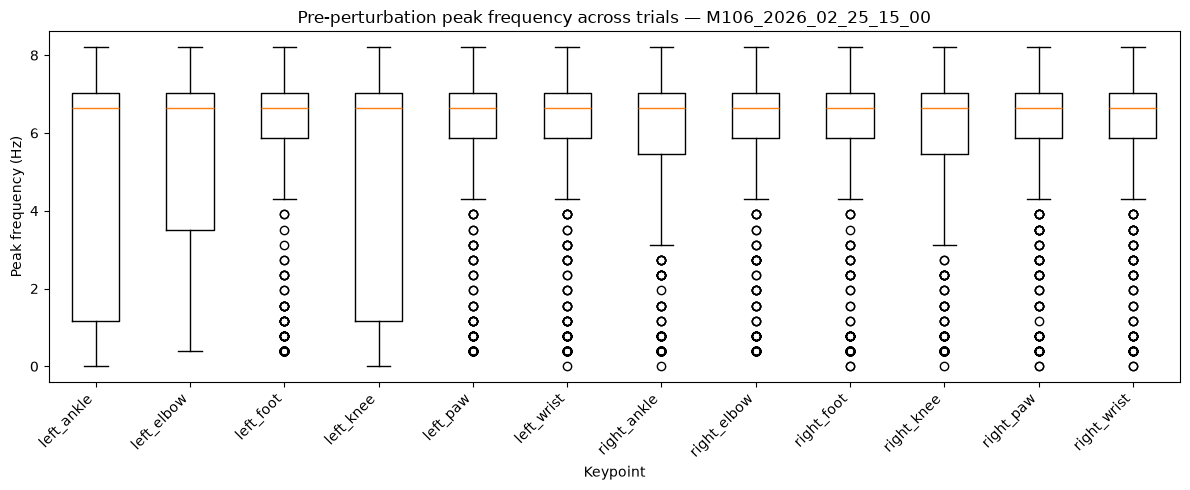

In [29]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(peak_freqs_arr, tick_labels=Params.oscillating_key_points)
ax.set_ylabel("Peak frequency (Hz)")
ax.set_xlabel("Keypoint")
ax.set_title(f"Pre-perturbation peak frequency across trials — {session}")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
df_perturb_score = kin.compute_power_in_bhv_concat_td(df)


411 / 499 trials pass the peak_mean_freq >= 2 Hz gate (82.4%)


In [10]:
df_perturb_score = kin.compute_perturb_score(
    df__, bhv_fields=Params.oscillating_key_points
)

add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
411 / 499 trials pass the peak_mean_freq >= 2 Hz gate (82.4%)


In [11]:
df_perturb_score

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,SSp_rates,sol_level_id,sol_contra_ipsi,bhv,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score
0,M106,M106_2026_02_25_15_00,0,free,48000,0.01,0,47999,[],1,...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",NaN,NaN,"[[-2.0598765903820424, 13.408386726679147, 194...",None,None,None,None,None,None
1,M106,M106_2026_02_25_15_00,1,intertrial,300,0.01,48000,48299,[],[],...,"[[0.6726428866386414, 0.0, 0.0, 0.0, 0.6726428...",NaN,NaN,"[[0.6319353284468224, 14.402034637143096, 192....",None,None,None,None,None,None
2,M106,M106_2026_02_25_15_00,2,trial,600,0.01,48300,48899,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 14.38696533441...",0.0,1.0,"[[4.7113735826335, 13.690610198263672, 194.104...","[[192.25682595866687, 175.95349464921964, 186....",500,300,"[[1.2456079450001143, 1.1763614363587633, 1.64...","[[-0.03103617700968566, -1.9180891007058731, -...","[0.025787896600722976, 0.18744391855646128, -0..."
3,M106,M106_2026_02_25_15_00,3,intertrial,100,0.01,48900,48999,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.81922650337...",NaN,NaN,"[[4.719819369216153, 13.883739337726473, 190.5...",None,None,None,None,None,None
4,M106,M106_2026_02_25_15_00,4,trial,600,0.01,49000,49599,[],[],...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 18.468809127807617,...",0.0,1.0,"[[4.293750991903091, 13.685706393891431, 194.8...","[[190.55076207954733, 176.0942658871152, 185.3...",300,100,"[[1.7733458841055916, 0.6911483343834861, 2.22...","[[2.123601015452111, 1.6522795470493394, 2.001...","[-0.8652581191544616, 0.04188148499683571, -0...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,M106,M106_2026_02_25_15_00,996,trial,600,0.01,496000,496599,[],[],...,"[[27.942845225334167, 0.0, 19.14145201444626, ...",0.0,0.0,"[[3.725165190426778, 14.257670140115824, 198.3...","[[202.9451057133885, 174.24232791539308, 201.9...",500,300,"[[1.7811410429160224, 0.554667607558075, 2.256...","[[-1.3204448472732013, -2.323731616749406, -1....","[-0.2448781945734474, -0.22151950739668205, -0..."
997,M106,M106_2026_02_25_15_00,997,intertrial,500,0.01,496600,497099,[],[],...,"[[0.002371225673414301, 1.5119582414627075, 0....",NaN,NaN,"[[3.215530813433844, 13.575365272984026, 194.7...",None,None,None,None,None,None
998,M106,M106_2026_02_25_15_00,998,trial,600,0.01,497100,497699,[],[],...,"[[2.185133844614029, 0.0, 13.992717862129211, ...",1.0,1.0,"[[1.2827552613207662, 13.901322697675694, 195....","[[194.70945733834083, 176.66048517103852, 189....",700,500,"[[1.3196770554724722, 0.35126471357078576, 1.9...","[[-1.6301222834764335, 1.6526444138932077, -1....","[0.22243034587665364, 0.038369293401571546, 0...."
999,M106,M106_2026_02_25_15_00,999,intertrial,100,0.01,497700,497799,[],[],...,"[[42.19643473625183, 0.0, 0.2694053342565894, ...",NaN,NaN,"[[0.1561075570568887, 13.853839884743657, 193....",None,None,None,None,None,None


# Effect of the freq_tresh=2 Hz gate (peak_mean_freq) on per-keypoint peak frequency

In [30]:
peak_mean_freqs = []
for idx, row in df.iterrows():
    if row.trial_name != "trial":
        continue
    perturb_idx = row.concat_perturb_time
    if perturb_idx is None:
        continue
    _, freqs, psd = kin.compute_peak_freq_pre_perturb(
        row.bhv_concat, perturb_idx=perturb_idx
    )
    peak_mean_freqs.append(freqs[np.argmax(psd.mean(-1), axis=0)])

peak_mean_freqs = np.array(peak_mean_freqs)
gate_mask = peak_mean_freqs >= 2  # mirrors freq_tresh in compute_power_in_bhv_concat_td

print(f"{gate_mask.sum()} / {len(gate_mask)} trials pass the peak_mean_freq >= 2 Hz gate ({gate_mask.mean():.1%})")
print(f"peak_mean_freq, all trials:     mean={peak_mean_freqs.mean():.2f} Hz  median={np.median(peak_mean_freqs):.2f} Hz")
print(f"peak_mean_freq, passing trials: mean={peak_mean_freqs[gate_mask].mean():.2f} Hz  median={np.median(peak_mean_freqs[gate_mask]):.2f} Hz")

412 / 499 trials pass the peak_mean_freq >= 2 Hz gate (82.6%)
peak_mean_freq, all trials:     mean=5.51 Hz  median=6.64 Hz
peak_mean_freq, passing trials: mean=6.56 Hz  median=6.64 Hz


Peak frequencies for 412 trials passing the 2 Hz gate
        left_ankle: mean= 5.93 Hz  median= 6.64 Hz  std= 2.15 Hz
        left_elbow: mean= 6.09 Hz  median= 6.64 Hz  std= 1.94 Hz
         left_foot: mean= 6.48 Hz  median= 6.64 Hz  std= 1.24 Hz
         left_knee: mean= 5.87 Hz  median= 6.64 Hz  std= 2.22 Hz
          left_paw: mean= 6.47 Hz  median= 6.64 Hz  std= 1.23 Hz
        left_wrist: mean= 6.46 Hz  median= 6.64 Hz  std= 1.23 Hz
       right_ankle: mean= 6.41 Hz  median= 6.64 Hz  std= 1.36 Hz
       right_elbow: mean= 6.54 Hz  median= 6.64 Hz  std= 1.06 Hz
        right_foot: mean= 6.47 Hz  median= 6.64 Hz  std= 1.26 Hz
        right_knee: mean= 6.40 Hz  median= 6.64 Hz  std= 1.34 Hz
         right_paw: mean= 6.55 Hz  median= 6.64 Hz  std= 0.98 Hz
       right_wrist: mean= 6.55 Hz  median= 6.64 Hz  std= 0.98 Hz


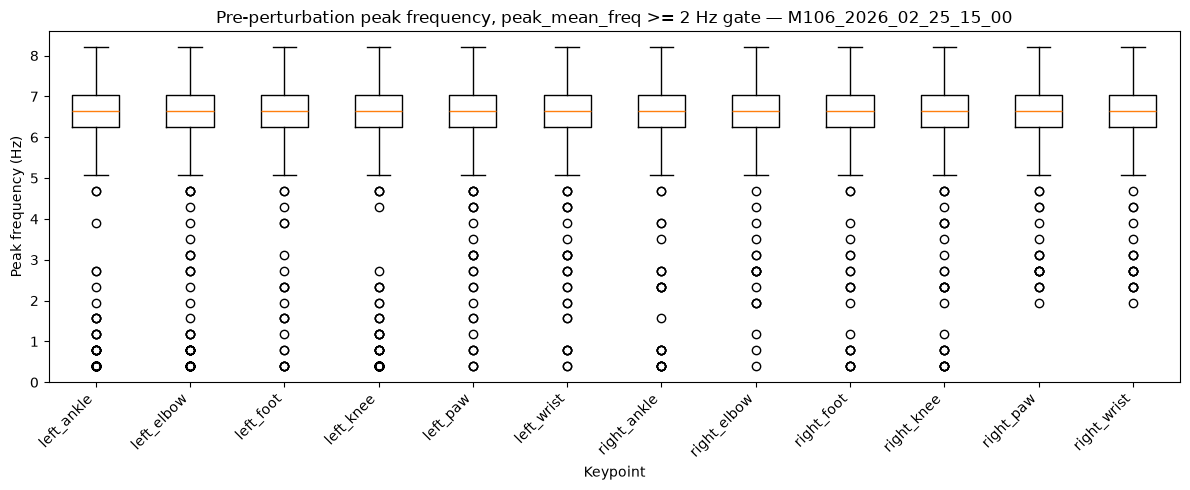

In [31]:
peak_freqs_gated = peak_freqs_arr[gate_mask]

print(f"Peak frequencies for {peak_freqs_gated.shape[0]} trials passing the 2 Hz gate")
for kp, mean_f, median_f, std_f in zip(
    Params.oscillating_key_points,
    peak_freqs_gated.mean(axis=0),
    np.median(peak_freqs_gated, axis=0),
    peak_freqs_gated.std(axis=0),
):
    print(f"  {kp:>16s}: mean={mean_f:5.2f} Hz  median={median_f:5.2f} Hz  std={std_f:5.2f} Hz")

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(peak_freqs_gated, tick_labels=Params.oscillating_key_points)
ax.set_ylabel("Peak frequency (Hz)")
ax.set_xlabel("Keypoint")
ax.set_title(f"Pre-perturbation peak frequency, peak_mean_freq >= 2 Hz gate — {session}")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Scroll through trials: raw traces, PSDs, power traces

No ipywidgets in this environment, so scrolling is manual: change `trial_idx` in the cell below and re-run it plus the three plotting cells that follow.

In [51]:
trial_rows = df_perturb_score[df_perturb_score.trial_name == "trial"].reset_index(drop=True)
print(f"{len(trial_rows)} perturbation trials available to scroll through (indices 0..{len(trial_rows) - 1})")

trial_idx = 1  # <-- change this and re-run this cell + the 3 plotting cells below

row = trial_rows.iloc[trial_idx]
perturb_idx = row.concat_perturb_time
has_power = isinstance(row.power, np.ndarray)
print(f"Trial {trial_idx}: concat_perturb_time={perturb_idx}, bhv_concat shape={row.bhv_concat.shape}, "
      f"power computed={has_power}")

499 perturbation trials available to scroll through (indices 0..498)
Trial 1: concat_perturb_time=300, bhv_concat shape=(700, 12), power computed=True


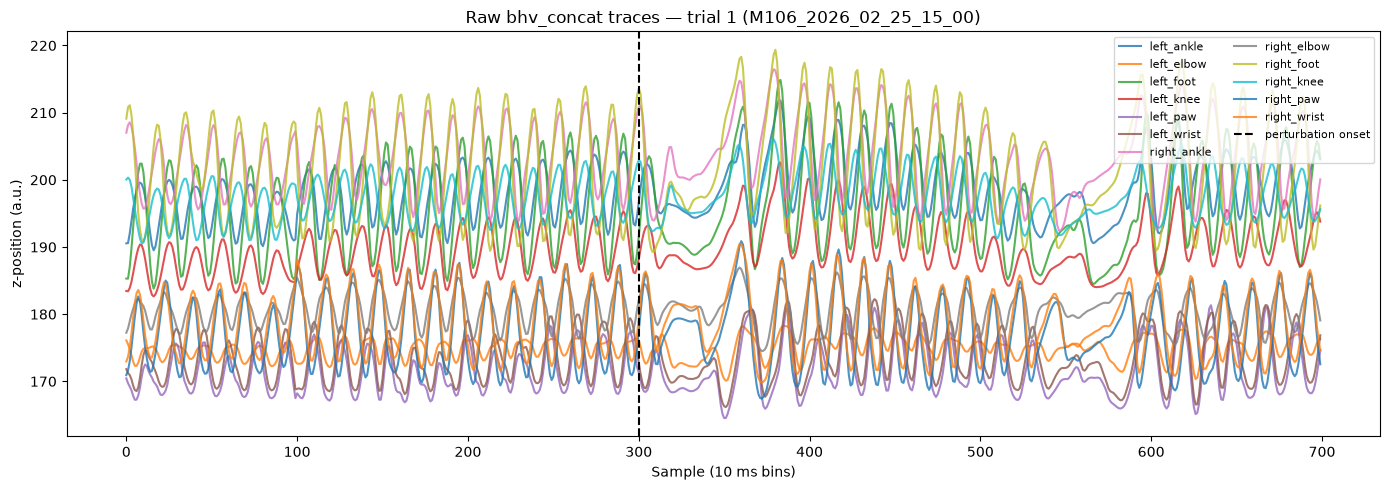

bhv_concat length: 700 samples, perturbation at sample 300


In [52]:
# 1) Raw traces (z-dimension of each keypoint, bhv_concat)
fig, ax = plt.subplots(figsize=(14, 5))
for i, kp in enumerate(Params.oscillating_key_points):
    ax.plot(row.bhv_concat[:, i], label=kp, alpha=0.8)
ax.axvline(perturb_idx, color="k", linestyle="--", label="perturbation onset")
ax.set_xlabel("Sample (10 ms bins)")
ax.set_ylabel("z-position (a.u.)")
ax.set_title(f"Raw bhv_concat traces — trial {trial_idx} ({session})")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(f"bhv_concat length: {row.bhv_concat.shape[0]} samples, perturbation at sample {perturb_idx}")

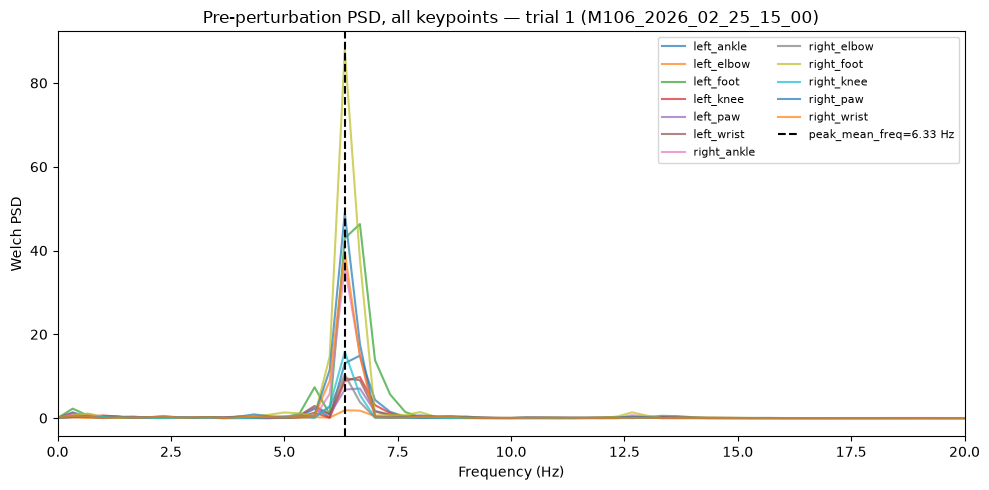

peak_mean_freq = 6.33 Hz
Per-keypoint peak freq (Hz): {'left_ankle': np.float64(6.67), 'left_elbow': np.float64(6.33), 'left_foot': np.float64(6.67), 'left_knee': np.float64(6.67), 'left_paw': np.float64(6.67), 'left_wrist': np.float64(6.33), 'right_ankle': np.float64(6.33), 'right_elbow': np.float64(6.33), 'right_foot': np.float64(6.33), 'right_knee': np.float64(6.33), 'right_paw': np.float64(6.33), 'right_wrist': np.float64(6.33)}


In [53]:
# 2) Overlapping pre-perturbation PSDs, all keypoints
peak_freqs, freqs, psd = kin.compute_peak_freq_pre_perturb(row.bhv_concat, perturb_idx=perturb_idx)
peak_mean_freq = freqs[np.argmax(psd.mean(-1), axis=0)]

fig, ax = plt.subplots(figsize=(10, 5))
for i, kp in enumerate(Params.oscillating_key_points):
    ax.plot(freqs, psd[:, i], label=kp, alpha=0.7)
ax.axvline(peak_mean_freq, color="k", linestyle="--", label=f"peak_mean_freq={peak_mean_freq:.2f} Hz")
ax.set_xlim(0, 20)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Welch PSD")
ax.set_title(f"Pre-perturbation PSD, all keypoints — trial {trial_idx} ({session})")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

print(f"peak_mean_freq = {peak_mean_freq:.2f} Hz")
print("Per-keypoint peak freq (Hz):", dict(zip(Params.oscillating_key_points, np.round(peak_freqs, 2))))

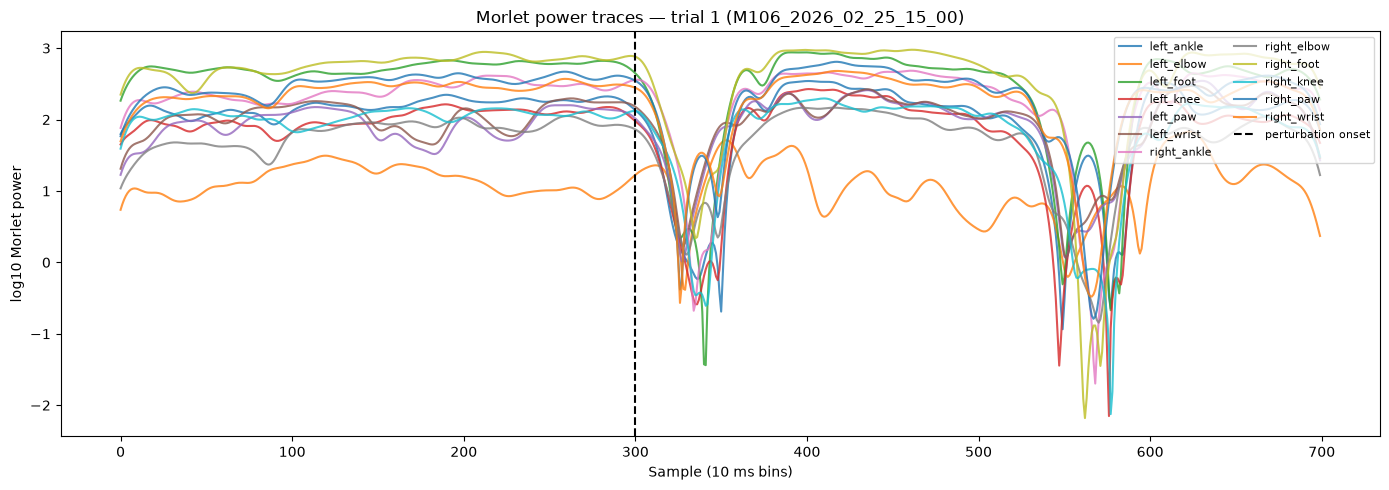

AttributeError: 'Series' object has no attribute 'disturb_score'

In [54]:
# 3) Morlet power traces (log10 power at peak_mean_freq), all keypoints
if not has_power:
    print(f"Trial {trial_idx} was skipped by the freq_tresh gate in compute_power_in_bhv_concat_td "
          f"(peak_mean_freq < 2 Hz) — no power/disturb_score available.")
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    for i, kp in enumerate(Params.oscillating_key_points):
        ax.plot(row.power[:, i], label=kp, alpha=0.8)
    ax.axvline(perturb_idx, color="k", linestyle="--", label="perturbation onset")
    ax.set_xlabel("Sample (10 ms bins)")
    ax.set_ylabel("log10 Morlet power")
    ax.set_title(f"Morlet power traces — trial {trial_idx} ({session})")
    ax.legend(loc="upper right", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    print("disturb_score per keypoint:", dict(zip(
        Params.oscillating_key_points, np.round(row.disturb_score, 2)
    )) if isinstance(row.disturb_score, np.ndarray) else "N/A")

# New loading implemented

In [4]:
SESSIONS = [
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # 'M086_2025_12_11_15_00',
    # 'M086_2025_12_10_15_00'
]

# td, _ = dsp.load_and_process_session(SESSIONS[0], std=0.03)
    

In [5]:
df = pyal.load_pyaldata("C:/data/raw/" + SESSIONS[0][:4] + "/" + SESSIONS[0])

C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")


In [6]:
df_prepro = dsp.preprocess(df, only_trials=False, combine_time_bins=False, std=0.03)

C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.9001996007984% of trials
  warnings.warn(


['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']
Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)


In [11]:
# df_tr = dt.add_bhv(df_prepro, bhv_fields=["all"])
df_tr = kin.compute_perturb_score(
    df_prepro, 
    on_keypoints=Params.oscillating_keypoints
)
# df_tr = pyal.select_trials(df_tr, df_tr.trial_name == "trial")



TypeError: compute_perturb_score() got an unexpected keyword argument 'on_keypoints'

In [18]:
mask_none = df_tr["power"].apply(lambda x: not isinstance(x, np.ndarray))

In [22]:
df_tr.power.values[12]

In [21]:
df_tr.loc[mask_none, ["trial_id", "trial_name"]]

,trial_id,trial_name
12,26,trial
15,32,trial
34,70,trial
66,134,trial
72,146,trial
...,...,...
441,884,trial
442,886,trial
443,888,trial
447,896,trial


In [23]:
vel = np.gradient(np.concatenate(td.bhv.values), axis=0)
speed = np.linalg.norm(vel, axis=1)
log_speed = np.log(np.maximum(speed, 1e-10))

In [28]:
vel.shape

(199200, 36)

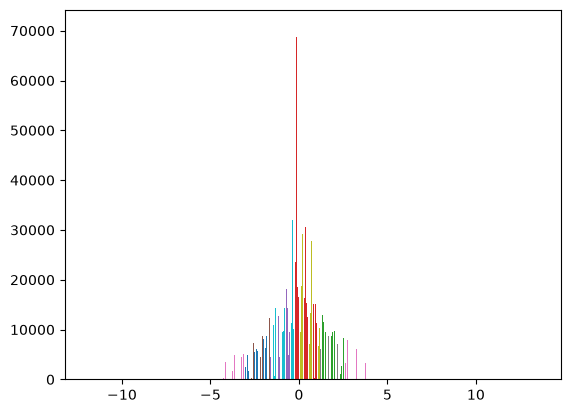

In [27]:
fig, ax = plt.subplots()
ax.hist(vel, bins=100)
plt.show()

In [19]:
df = dt.add_pca_df(df_prepro.iloc[1:])

# 4 — perturbation metric (requires behavioural data; skip gracefully if absent)
try:
    df = kin.compute_perturb_score(df, bhv_fields=Params.oscillating_key_points)
except Exception as e:
    print(
        f"  WARNING: compute_perturb_score failed ({e}). "
        f"Skipping disturbance metric and trial dropping."
    )

# 5 — filter trials
df_tr = pyal.select_trials(df, df.trial_name == "trial")

df_tr = kin.drop_immobile_trials(df_tr, min_immobile_bins=5)
mask = df_tr["disturb_score"].apply(
    lambda x: isinstance(x, np.ndarray) and not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

# 6 — derived metrics + sort order
df_tr["disturb_mean"] = df_tr["disturb_score"].apply(np.mean)
df_tr["disturb_sum"] = df_tr["disturb_score"].apply(
    lambda a: np.log10(np.abs(np.sum(a)))
)
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
compute_power_in_bhv_concat_td: dropping 88 trial(s) with peak_mean_freq < 2 Hz
Otsu immobility threshold: 2.2123
Dropped 130 of 499 rows (26.05%).
